# Daniel Phase 1 — QPINN Reproduction & Benchmarking

**ETH Quantum Hackathon 2026 — Quandela Challenge**

This notebook implements **Phase 1: Reproduction** of the QPINN challenge.
We solve the 1D heat equation with:
1. A **classical PINN baseline** (direct and auxiliary derivative)
2. A **MerLin DV-photonic QPINN** (hybrid quantum-classical)

This implementation should be interpreted as a MerLin-compatible discrete-variable photonic surrogate reproduction of the QPINN idea, rather than a literal continuous-variable Strawberry Fields reproduction of the reference architecture.
All models are trained under **fair conditions** for the main comparison (same data budget, optimizer, epochs, and approximately matched parameter counts). Efficiency sweeps are exploratory single-seed runs and not strictly parameter matched.

*Code is adapted from the two provided starter notebooks:*
- `mlp_pinn_heat_equation_ETH_hackathon.ipynb`
- `merlin_dv_qpinn_ETH_hackathon.ipynb`


In [1]:
import math
import time
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, List

# MerLin import
import merlin as ML

# Reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device and dtype
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)

print('Device:', DEVICE)
print('Torch version:', torch.__version__)
print('MerLin version:', getattr(ML, '__version__', 'unknown'))
import pandas as pd
import os

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_fig(name: str, fig=None, dpi: int = 200):
    """Save the current figure to results/ with a stable name."""
    if fig is None:
        fig = plt.gcf()
    path = os.path.join(RESULTS_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

Device: cpu
Torch version: 2.10.0+cpu
MerLin version: 0.2.3


## Problem Definition: 1D Heat Equation

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad x \in [0,1], \; t \in [0,1]$$

Exact solution (used for IC and evaluation):
$$u(x,t) = e^{-\alpha \pi^2 t} \sin(\pi x)$$

Boundary conditions: $u(0,t) = u(1,t) = 0$
Initial condition: $u(x,0) = \sin(\pi x)$


In [2]:
alpha = 0.1

def exact_u(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """Exact solution of the heat equation."""
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)

def sample_interior(n: int, device=DEVICE, dtype=DTYPE) -> torch.Tensor:
    x = torch.rand(n, 1, device=device, dtype=dtype)
    t = torch.rand(n, 1, device=device, dtype=dtype)
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad_(True)
    return xt

def sample_initial(n: int, device=DEVICE, dtype=DTYPE) -> Tuple[torch.Tensor, torch.Tensor]:
    x = torch.rand(n, 1, device=device, dtype=dtype)
    t = torch.zeros_like(x)
    xt = torch.cat([x, t], dim=1)
    y = exact_u(x, t)
    return xt, y

def sample_boundary(n: int, device=DEVICE, dtype=DTYPE) -> Tuple[torch.Tensor, torch.Tensor]:
    n0 = n // 2
    n1 = n - n0
    t0 = torch.rand(n0, 1, device=device, dtype=dtype)
    t1 = torch.rand(n1, 1, device=device, dtype=dtype)
    x0 = torch.zeros_like(t0)
    x1 = torch.ones_like(t1)
    xt = torch.cat([torch.cat([x0, t0], dim=1), torch.cat([x1, t1], dim=1)], dim=0)
    y = torch.zeros(n, 1, device=device, dtype=dtype)
    return xt, y


In [3]:
def gradients(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """Compute dy/dx via autograd."""
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


## Classical PINN Baseline — Direct Second Derivative

Adapted from `mlp_pinn_heat_equation_ETH_hackathon.ipynb`.
Standard MLP that computes $u_{\theta}(x,t)$ and evaluates the PDE residual $u_t - \alpha u_{xx}$ using nested automatic differentiation.


In [4]:
class ClassicalPINN(nn.Module):
    def __init__(self, hidden: int = 32, depth: int = 4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, xt: torch.Tensor) -> torch.Tensor:
        return self.net(xt)

def pde_residual_direct(model: nn.Module, xt: torch.Tensor) -> torch.Tensor:
    """Compute u_t - alpha * u_xx."""
    u = model(xt)
    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]
    grad_ux = gradients(u_x, xt)
    u_xx = grad_ux[:, 0:1]
    return u_t - alpha * u_xx

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## Classical PINN Baseline — Auxiliary Derivative (Ablation)

Adapted from `mlp_pinn_heat_equation_ETH_hackathon.ipynb`.
This is a classical ablation of the auxiliary-derivative consistency trick used in the QPINN formulation.
The network outputs both $u$ and $\hat{u}_x$. The PDE residual becomes $u_t - \alpha \partial_x \hat{u}_x$, and a consistency loss enforces $\hat{u}_x \approx \partial_x u$.

In [5]:
class ClassicalAuxPINN(nn.Module):
    def __init__(self, hidden: int = 32, depth: int = 4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 2))  # [u, ux_hat]
        self.net = nn.Sequential(*layers)

    def forward(self, xt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        y = self.net(xt)
        return y[:, 0:1], y[:, 1:2]

def pde_residual_aux(model: nn.Module, xt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """Compute residual and consistency for auxiliary formulation."""
    u, ux_hat = model(xt)
    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]
    grad_ux_hat = gradients(ux_hat, xt)
    ux_hat_x = grad_ux_hat[:, 0:1]
    residual = u_t - alpha * ux_hat_x
    consistency = u_x - ux_hat
    return residual, consistency


## MerLin DV-Photonic QPINN

Adapted from `merlin_dv_qpinn_ETH_hackathon.ipynb`.
Hybrid quantum-classical model using MerLin's `QuantumLayer.simple`. The architecture:
1. Classical feature map: $(x,t) \mapsto z$
2. MerLin quantum layer: $z \mapsto q$
3. Classical readout: $q \mapsto [q_u, \hat{u}_x]$
4. Hard-coded BC: $u = x(1-x) \cdot q_u$


In [6]:
class MerlinQPINN(nn.Module):
    def __init__(self, feature_size: int = 4, quantum_output_size: int = 4, hidden: int = 16):
        super().__init__()
        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, feature_size),
        )
        self.quantum = ML.QuantumLayer.simple(
            input_size=feature_size,
            output_size=quantum_output_size,
        )
        self.readout = nn.Sequential(
            nn.Linear(quantum_output_size, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = xt[:, 0:1]
        z = self.feature_map(xt)
        q = self.quantum(z)
        out = self.readout(q)
        q_u = out[:, 0:1]
        ux_hat = out[:, 1:2]
        u = x * (1.0 - x) * q_u  # hard-coded Dirichlet BC
        return u, ux_hat

def pde_residual_merlin(model: nn.Module, xt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """PDE residual + consistency for MerLin model."""
    u, ux_hat = model(xt)
    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]
    grad_ux_hat = gradients(ux_hat, xt)
    ux_hat_x = grad_ux_hat[:, 0:1]
    residual = u_t - alpha * ux_hat_x
    consistency = u_x - ux_hat
    return residual, consistency


## Training Configuration

We use a single `TrainConfig` dataclass for **all** models to ensure fair comparison.

**Important:** the MerLin starter notebook was carefully tuned with:
- `lr = 1e-2`
- `lambda_consistency = 0.1`
- `lambda_bc = 1.0`
- `n_f = n_i = n_b = 64`

Deviating from these values (e.g. lowering the learning rate or increasing the consistency weight)
noticeably degrades the MerLin QPINN result, so we keep the original tuned hyperparameters here.

Classical baselines are trained under the *same* settings for a fair benchmark.


In [7]:
@dataclass
class TrainConfig:
    epochs: int = 300
    n_f: int = 64       # original merlin value
    n_i: int = 64
    n_b: int = 64
    lr: float = 1e-2    # tuned for MerLin quantum layer (higher than classical default)
    lambda_pde: float = 1.0
    lambda_ic: float = 10.0
    lambda_bc: float = 1.0     # original value (BC is near-zero by construction)
    lambda_consistency: float = 0.1  # original value: do not over-penalise auxiliary derivative
    lambda_trace: float = 0.0   # trace loss if available; unused when state is not exposed
    print_every: int = 25

config = TrainConfig()
print(config)

TrainConfig(epochs=300, n_f=64, n_i=64, n_b=64, lr=0.01, lambda_pde=1.0, lambda_ic=10.0, lambda_bc=1.0, lambda_consistency=0.1, lambda_trace=0.0, print_every=25)


## Unified Training Loop

We train each model with the **same** config and record:
- Total loss, PDE residual, IC loss, BC loss
- (Where applicable) consistency loss and trace loss
- Wall-clock training time
- Relative $L^2$ error on a dense evaluation grid

Loss definitions differ by model: Direct PINN uses PDE+IC+BC only; Auxiliary PINN and MerLin DV-QPINN add consistency loss; trace loss is included only if the quantum state normalization is accessible (not exposed by the MerLin layer used here).

In [8]:
def train_model(
    model: nn.Module,
    config: TrainConfig,
    use_aux: bool = False,
    is_merlin: bool = False,
    trace_loss_fn=None,
    device: torch.device = DEVICE,
    dtype: torch.dtype = DTYPE,
 ):
    """Train a PINN model and return history + metrics."""
    model = model.to(device=device, dtype=dtype)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
    mse = nn.MSELoss()

    history = {"total": [], "pde": [], "ic": [], "bc": []}
    if is_merlin or use_aux:
        history["consistency"] = []
    if trace_loss_fn is not None:
        history["trace"] = []
    start = time.time()

    for epoch in range(1, config.epochs + 1):
        optimizer.zero_grad()

        xt_f = sample_interior(config.n_f, device=device, dtype=dtype)
        xt_i, y_i = sample_initial(config.n_i, device=device, dtype=dtype)
        xt_b, y_b = sample_boundary(config.n_b, device=device, dtype=dtype)

        if is_merlin or use_aux:
            if is_merlin:
                r_f, r_c = pde_residual_merlin(model, xt_f)
            else:
                r_f, r_c = pde_residual_aux(model, xt_f)
            loss_pde = mse(r_f, torch.zeros_like(r_f))
            loss_consistency = mse(r_c, torch.zeros_like(r_c))
            u_i, _ = model(xt_i)
            u_b, _ = model(xt_b)
        else:
            r_f = pde_residual_direct(model, xt_f)
            loss_pde = mse(r_f, torch.zeros_like(r_f))
            loss_consistency = None
            u_i = model(xt_i)
            u_b = model(xt_b)

        loss_ic = mse(u_i, y_i)
        loss_bc = mse(u_b, y_b)

        loss_trace = trace_loss_fn(model, xt_f) if trace_loss_fn is not None else None

        loss = (
            config.lambda_pde * loss_pde
            + config.lambda_ic * loss_ic
            + config.lambda_bc * loss_bc
        )
        if loss_consistency is not None:
            loss = loss + config.lambda_consistency * loss_consistency
        if loss_trace is not None:
            loss = loss + config.lambda_trace * loss_trace

        loss.backward()
        optimizer.step()

        history["total"].append(loss.item())
        history["pde"].append(loss_pde.item())
        history["ic"].append(loss_ic.item())
        history["bc"].append(loss_bc.item())
        if loss_consistency is not None:
            history["consistency"].append(loss_consistency.item())
        if loss_trace is not None:
            history["trace"].append(loss_trace.item())

        if epoch % config.print_every == 0 or epoch == 1:
            msg = (
                f"Epoch {epoch:4d} | loss={loss.item():.3e} | "
                f"pde={loss_pde.item():.3e} | ic={loss_ic.item():.3e} | "
                f"bc={loss_bc.item():.3e}"
            )
            if loss_consistency is not None:
                msg += f" | cons={loss_consistency.item():.3e}"
            if loss_trace is not None:
                msg += f" | trace={loss_trace.item():.3e}"
            print(msg)

    elapsed = time.time() - start
    return history, elapsed

## Evaluation on a Uniform Grid

We evaluate every model on the **same** $101 \times 101$ grid and compute the relative $L^2$ error:
$$\frac{\|u_\theta - u_{\text{true}}\|_2}{\|u_{\text{true}}\|_2}$$


In [9]:
def evaluate_model(model: nn.Module, use_aux: bool = False, is_merlin: bool = False, nx: int = 101, nt: int = 101):
    with torch.no_grad():
        x = torch.linspace(0, 1, nx, device=DEVICE, dtype=DTYPE).view(-1, 1)
        t = torch.linspace(0, 1, nt, device=DEVICE, dtype=DTYPE).view(-1, 1)
        X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
        xt = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

        if use_aux or is_merlin:
            u_pred, _ = model(xt)
        else:
            u_pred = model(xt)

        u_pred = u_pred.reshape(nx, nt)
        u_true = exact_u(X, T)

        diff = u_pred - u_true
        rel_l2 = torch.linalg.norm(diff) / torch.linalg.norm(u_true)
        rmse = torch.sqrt(torch.mean(diff**2))
        mae = torch.mean(torch.abs(diff))
        max_abs = torch.max(torch.abs(diff))

    # PDE residual needs gradients
    xi = torch.rand(2000, 1, device=DEVICE, dtype=DTYPE)
    ti = torch.rand(2000, 1, device=DEVICE, dtype=DTYPE)
    xti = torch.cat([xi, ti], dim=1)
    xti.requires_grad_(True)
    if is_merlin:
        r, _ = pde_residual_merlin(model, xti)
    elif use_aux:
        r, _ = pde_residual_aux(model, xti)
    else:
        r = pde_residual_direct(model, xti)
    pde_mse = torch.mean(r**2).item()

    return (
        X.detach().cpu(), T.detach().cpu(), u_pred.detach().cpu(), u_true.detach().cpu(),
        rel_l2.item(), rmse.item(), mae.item(), max_abs.item(), pde_mse
    )


## Matching Parameter Counts

For a fair comparison we resize the classical MLP so its total trainable parameters are close to the MerLin hybrid model. We print counts before training.


In [10]:
merlin_model = MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16)
merlin_params = count_parameters(merlin_model)
print(f"MerLin QPINN parameters: {merlin_params}")

# Find closest classical MLP by grid search (include small nets)
best_diff = float('inf')
classical_hidden, classical_depth = 32, 4
for hidden, depth in [(8,2),(12,2),(16,2),(32,2),(64,2),(8,3),(12,3),(16,3),(32,3),(8,4),(12,4),(16,4)]:
    p = count_parameters(ClassicalPINN(hidden=hidden, depth=depth))
    print(f"ClassicalPINN(hidden={hidden}, depth={depth}) -> {p} params")
    if abs(p - merlin_params) < best_diff:
        best_diff = abs(p - merlin_params)
        classical_hidden, classical_depth = hidden, depth

print(f"\nSelected classical baseline: hidden={classical_hidden}, depth={classical_depth} (diff={best_diff})")

# Same for auxiliary MLP
best_diff = float('inf')
aux_hidden, aux_depth = 32, 4
for hidden, depth in [(8,2),(12,2),(14,2),(16,2),(32,2),(64,2),(8,3),(12,3),(14,3),(16,3),(32,3),(8,4),(12,4),(14,4),(16,4)]:
    p = count_parameters(ClassicalAuxPINN(hidden=hidden, depth=depth))
    print(f"ClassicalAuxPINN(hidden={hidden}, depth={depth}) -> {p} params")
    if abs(p - merlin_params) < best_diff:
        best_diff = abs(p - merlin_params)
        aux_hidden, aux_depth = hidden, depth

print(f"Selected aux baseline:       hidden={aux_hidden}, depth={aux_depth} (diff={best_diff})")


MerLin QPINN parameters: 270
ClassicalPINN(hidden=8, depth=2) -> 105 params
ClassicalPINN(hidden=12, depth=2) -> 205 params
ClassicalPINN(hidden=16, depth=2) -> 337 params
ClassicalPINN(hidden=32, depth=2) -> 1185 params
ClassicalPINN(hidden=64, depth=2) -> 4417 params
ClassicalPINN(hidden=8, depth=3) -> 177 params
ClassicalPINN(hidden=12, depth=3) -> 361 params
ClassicalPINN(hidden=16, depth=3) -> 609 params
ClassicalPINN(hidden=32, depth=3) -> 2241 params
ClassicalPINN(hidden=8, depth=4) -> 249 params
ClassicalPINN(hidden=12, depth=4) -> 517 params
ClassicalPINN(hidden=16, depth=4) -> 881 params

Selected classical baseline: hidden=8, depth=4 (diff=21)
ClassicalAuxPINN(hidden=8, depth=2) -> 114 params
ClassicalAuxPINN(hidden=12, depth=2) -> 218 params
ClassicalAuxPINN(hidden=14, depth=2) -> 282 params
ClassicalAuxPINN(hidden=16, depth=2) -> 354 params
ClassicalAuxPINN(hidden=32, depth=2) -> 1218 params
ClassicalAuxPINN(hidden=64, depth=2) -> 4482 params
ClassicalAuxPINN(hidden=8, dep

In [11]:
# ============================================================
# Experiment Control & Result Caching
# ============================================================

FORCE_RETRAIN = False
RUN_SWEEPS = True

LOSS_PROTOCOL = "corrected_phase1_v2"
MODEL_LABELS = {
    "Direct": "Direct PINN",
    "Aux": "Auxiliary PINN ablation",
    "MerLin": "MerLin DV-QPINN",
    "ClassicalAux": "Auxiliary PINN ablation",
}

MAIN_EPOCHS = 300
MAIN_SEEDS = [0, 1, 2]

SWEEP_EPOCHS = 150
SWEEP_SEEDS = [0]

SAMPLE_NF_VALUES = [100, 500, 1000]
PARAMETER_SIZE_SETTINGS = ["small", "medium", "large"]

# Size definitions for parameter Pareto
CLASSICAL_SIZE_MAP = {
    "small":  (8, 2),
    "medium": (16, 4),
    "large":  (32, 4),
}
MERLIN_SIZE_MAP = {
    "small":  (2, 2),
    "medium": (4, 4),
    "large":  (8, 8),
}

os.makedirs("results", exist_ok=True)

RESULT_COLS = [
    "analysis", "model", "seed", "epochs", "n_f", "size", "loss_protocol",
    "params", "rel_l2", "rmse", "mae", "max_err", "pde_mse",
    "final_loss", "time", "cached",
]

def _row_key(analysis, model, seed, epochs, n_f, size, loss_protocol):
    return f"{analysis}|{model}|{seed}|{epochs}|{n_f}|{size}|{loss_protocol}"

def _load_results(path):
    if os.path.exists(path) and not FORCE_RETRAIN:
        df = pd.read_csv(path)
        if "loss_protocol" not in df.columns:
            df["loss_protocol"] = "legacy"
        if "analysis" not in df.columns:
            df["analysis"] = ""
        if "size" not in df.columns:
            df["size"] = ""
        df["size"] = df["size"].fillna("").astype(str)
        df["analysis"] = df["analysis"].fillna("").astype(str)
        if "_key" not in df.columns:
            df["_key"] = df.apply(
                lambda r: _row_key(r["analysis"], r["model"], r["seed"], r["epochs"], r["n_f"], r["size"], r["loss_protocol"]),
                axis=1,
            )
        df = df.drop_duplicates(subset=["_key"], keep="last")
        return df
    return pd.DataFrame(columns=RESULT_COLS + ["_key"])

def _filter_protocol(df, protocol=LOSS_PROTOCOL):
    if "loss_protocol" in df.columns:
        return df[df["loss_protocol"] == protocol].copy()
    return df.copy()

def _save_results(df, path):
    df.drop(columns=["_key"], errors="ignore").to_csv(path, index=False)

def _load_clean_for_analysis(path, analysis, protocol=LOSS_PROTOCOL):
    df = _load_results(path).copy()
    if df.empty:
        return df
    df = df[df["analysis"] == analysis].copy()
    if "loss_protocol" not in df.columns:
        df["loss_protocol"] = "legacy"
    df = df[df["loss_protocol"] == protocol].copy()

    dedup_cols = [c for c in ["analysis", "model", "seed", "epochs", "n_f", "size", "loss_protocol"] if c in df.columns]
    if dedup_cols:
        n_before = len(df)
        df = df.drop_duplicates(subset=dedup_cols, keep="last").copy()
        n_removed = n_before - len(df)
        if n_removed > 0:
            print(f"[CLEAN] Removed {n_removed} duplicate rows from {path} for analysis={analysis}.")

    for col in ["seed", "epochs", "n_f", "params", "rel_l2", "pde_mse", "time"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "size" in df.columns:
        df["size"] = df["size"].fillna("").astype(str)
    return df

def _diag_table(df, title):
    print(f"\n=== Diagnostics: {title} ===")
    if df.empty:
        print("No rows after filtering.")
        return

    def _sorted_unique(series):
        vals = sorted(pd.unique(series.dropna()).tolist())
        return vals

    out = (
        df.groupby(["analysis", "model", "loss_protocol"], dropna=False)
          .agg(
              rows=("model", "size"),
              seeds=("seed", _sorted_unique),
              epochs=("epochs", _sorted_unique),
              n_f_values=("n_f", _sorted_unique),
              params_min=("params", "min"),
              params_max=("params", "max"),
              rel_l2_min=("rel_l2", "min"),
              rel_l2_max=("rel_l2", "max"),
              pde_mse_min=("pde_mse", "min"),
              pde_mse_max=("pde_mse", "max"),
          )
          .reset_index()
    )
    print(out.to_string(index=False))

def _assert_single_protocol(df, protocol, context):
    prots = sorted(pd.unique(df["loss_protocol"]).tolist()) if len(df) else []
    assert len(prots) <= 1, f"{context}: mixed loss protocols in plotted rows: {prots}"
    if len(prots) == 1:
        assert prots[0] == protocol, f"{context}: expected protocol={protocol}, got {prots[0]}"

def _assert_models_present(df, expected_models, context):
    present = set(df["model"].unique().tolist())
    missing = [m for m in expected_models if m not in present]
    assert not missing, f"{context}: missing required models {missing}; present={sorted(present)}"

def _print_rows_used(df, context, cols):
    print(f"\n=== Rows used for {context} ===")
    keep = [c for c in cols if c in df.columns]
    print(df[keep].sort_values([c for c in ["model", "seed", "size", "n_f"] if c in keep]).to_string(index=False))

def _plot_line_or_marker(ax, x, y, label, color):
    if len(x) <= 1 or pd.Series(x).nunique() <= 1:
        ax.plot(x, y, marker="o", linestyle="None", color=color, label=label)
    else:
        ax.plot(x, y, marker="o", linestyle="-", color=color, label=label)

def run_cached(analysis, model_name, build_fn, cfg, seed,
               csv_path, n_f=None, size=None, use_aux=False, is_merlin=False):
    df = _load_results(csv_path)
    n_f_val = n_f if n_f is not None else cfg.n_f
    size_val = size if size is not None else ""
    key = _row_key(analysis, model_name, seed, cfg.epochs, n_f_val, size_val, LOSS_PROTOCOL)

    if not FORCE_RETRAIN and key in df["_key"].values:
        row = df[df["_key"] == key].iloc[0].to_dict()
        row["cached"] = True
        print(f"  [CACHE] {model_name} s={seed} e={cfg.epochs} nf={n_f_val} sz={size_val} -> rel_l2={row['rel_l2']:.4e}")
        return row

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = build_fn()
    if is_merlin:
        for p in model.parameters():
            if p.is_floating_point():
                p.data = p.data.to(DTYPE)

    hist, elapsed = train_model(model, cfg, use_aux=use_aux, is_merlin=is_merlin)
    *_, rel_l2, rmse, mae, max_err, pde_mse = evaluate_model(model, use_aux=use_aux, is_merlin=is_merlin)

    row = {
        "analysis": analysis,
        "model": model_name,
        "seed": seed,
        "epochs": cfg.epochs,
        "n_f": n_f_val,
        "size": size_val,
        "loss_protocol": LOSS_PROTOCOL,
        "params": count_parameters(model),
        "rel_l2": rel_l2,
        "rmse": rmse,
        "mae": mae,
        "max_err": max_err,
        "pde_mse": pde_mse,
        "final_loss": hist["total"][-1],
        "time": elapsed,
        "cached": False,
        "_key": key,
    }
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    _save_results(df, csv_path)
    print(f"  [FRESH] {model_name} s={seed} e={cfg.epochs} nf={n_f_val} sz={size_val} -> rel_l2={rel_l2:.4e} ({elapsed:.1f}s)")
    return row

## Run All Experiments

We train three models under the same training budget:
1. **Direct PINN**
2. **Auxiliary PINN ablation**
3. **MerLin DV-QPINN**

Loss definitions differ as described in the Methods section.

In [12]:
# ============================================================
# Tier 1: Main Comparison
# ============================================================

main_cfg = TrainConfig(epochs=MAIN_EPOCHS, lr=1e-2, print_every=25)
main_csv = "results/main_comparison_results.csv"

# Train representative models for plots (first seed)
rep_seed = MAIN_SEEDS[0]
torch.manual_seed(rep_seed); np.random.seed(rep_seed); random.seed(rep_seed)

print("Training representative models (for plots)...")
clf_model = ClassicalPINN(hidden=classical_hidden, depth=classical_depth)
clf_history, clf_time = train_model(clf_model, main_cfg, use_aux=False, is_merlin=False)
clf_eval = evaluate_model(clf_model, use_aux=False, is_merlin=False)

aux_model = ClassicalAuxPINN(hidden=aux_hidden, depth=aux_depth)
aux_history, aux_time = train_model(aux_model, main_cfg, use_aux=True, is_merlin=False)
aux_eval = evaluate_model(aux_model, use_aux=True, is_merlin=False)

merlin_model = MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16)
for p in merlin_model.parameters():
    if p.is_floating_point():
        p.data = p.data.to(DTYPE)
merlin_history, merlin_time = train_model(merlin_model, main_cfg, use_aux=True, is_merlin=True)
merlin_eval = evaluate_model(merlin_model, use_aux=True, is_merlin=True)

# Seed the cache with representative runs
df_main = _load_results(main_csv)
for model_name, model_obj, hist, elapsed, use_aux, is_merlin in [
    ("Direct", clf_model, clf_history, clf_time, False, False),
    ("Aux", aux_model, aux_history, aux_time, True, False),
    ("MerLin", merlin_model, merlin_history, merlin_time, True, True),
]:
    *_, rel_l2, rmse, mae, max_err, pde_mse = evaluate_model(model_obj, use_aux=use_aux, is_merlin=is_merlin)
    row = {
        "analysis": "main", "model": model_name, "seed": rep_seed,
        "epochs": MAIN_EPOCHS, "n_f": main_cfg.n_f, "size": "",
        "loss_protocol": LOSS_PROTOCOL,
        "params": count_parameters(model_obj), "rel_l2": rel_l2,
        "rmse": rmse, "mae": mae, "max_err": max_err, "pde_mse": pde_mse,
        "final_loss": hist["total"][-1], "time": elapsed, "cached": False,
        "_key": _row_key("main", model_name, rep_seed, MAIN_EPOCHS, main_cfg.n_f, "", LOSS_PROTOCOL),
    }
    df_main = pd.concat([df_main, pd.DataFrame([row])], ignore_index=True)
df_main = df_main.drop_duplicates(subset=["_key"], keep="last")
_save_results(df_main, main_csv)

# Cache remaining seeds (rep_seed will hit cache)
for seed in MAIN_SEEDS:
    run_cached("main", "Direct",
               lambda: ClassicalPINN(hidden=classical_hidden, depth=classical_depth),
               main_cfg, seed, main_csv, use_aux=False, is_merlin=False)
    run_cached("main", "Aux",
               lambda: ClassicalAuxPINN(hidden=aux_hidden, depth=aux_depth),
               main_cfg, seed, main_csv, use_aux=True, is_merlin=False)
    run_cached("main", "MerLin",
               lambda: MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16),
               main_cfg, seed, main_csv, use_aux=True, is_merlin=True)

# Summary table
df_main = _filter_protocol(_load_results(main_csv).drop(columns=["_key"], errors="ignore"))
if df_main.empty:
    print(f"No rows found for loss protocol: {LOSS_PROTOCOL}. Run the main comparison to regenerate.")
else:
    summary = []
    for mname in ["Direct", "Aux", "MerLin"]:
        sub = df_main[df_main["model"] == mname]
        if len(sub) == 0:
            continue
        summary.append({
            "Model": MODEL_LABELS.get(mname, mname),
            "Rel L2": f"{sub['rel_l2'].mean():.4e} +/- {sub['rel_l2'].std():.4e}",
            "RMSE": f"{sub['rmse'].mean():.4e} +/- {sub['rmse'].std():.4e}",
            "PDE MSE": f"{sub['pde_mse'].mean():.4e} +/- {sub['pde_mse'].std():.4e}",
            "Time (s)": f"{sub['time'].mean():.1f} +/- {sub['time'].std():.1f}",
            "Params": int(sub["params"].iloc[0]),
            "Epochs": MAIN_EPOCHS,
            "N_f": main_cfg.n_f,
        })

    df_main_summary = pd.DataFrame(summary)
    print("\n=== Main Comparison (mean +/- std over seeds) ===")
    print(df_main_summary.to_string(index=False))

Training representative models (for plots)...
Epoch    1 | loss=4.086e+00 | pde=3.781e-05 | ic=4.084e-01 | bc=1.853e-03
Epoch   25 | loss=1.169e+00 | pde=6.652e-03 | ic=9.013e-02 | bc=2.609e-01
Epoch   50 | loss=1.258e+00 | pde=6.554e-02 | ic=9.264e-02 | bc=2.658e-01
Epoch   75 | loss=1.030e+00 | pde=4.867e-02 | ic=7.962e-02 | bc=1.852e-01
Epoch  100 | loss=1.017e+00 | pde=4.927e-02 | ic=7.934e-02 | bc=1.745e-01
Epoch  125 | loss=3.412e-01 | pde=1.886e-01 | ic=1.221e-02 | bc=3.046e-02
Epoch  150 | loss=4.473e-02 | pde=2.619e-02 | ic=1.386e-03 | bc=4.674e-03
Epoch  175 | loss=1.391e-02 | pde=8.578e-03 | ic=3.168e-04 | bc=2.161e-03
Epoch  200 | loss=8.440e-03 | pde=7.106e-03 | ic=8.744e-05 | bc=4.596e-04
Epoch  225 | loss=5.671e-03 | pde=4.562e-03 | ic=1.022e-04 | bc=8.654e-05
Epoch  250 | loss=3.093e-03 | pde=1.956e-03 | ic=6.960e-05 | bc=4.403e-04
Epoch  275 | loss=3.033e-03 | pde=2.308e-03 | ic=5.895e-05 | bc=1.351e-04
Epoch  300 | loss=2.947e-03 | pde=1.486e-03 | ic=1.352e-04 | bc=1.

## Quantitative Results


In [13]:
# Load cached main comparison for display
df_main = _filter_protocol(_load_results("results/main_comparison_results.csv").drop(columns=["_key"], errors="ignore"))

print("=== Representative Run (seed {}) ===".format(MAIN_SEEDS[0]))
def _final_or_na(hist, key):
    return hist[key][-1] if key in hist else "N/A"
rep_rows = []
for key, label, model_obj, elapsed, ev, hist in [
    ("Direct", MODEL_LABELS["Direct"], clf_model, clf_time, clf_eval, clf_history),
    ("Aux", MODEL_LABELS["Aux"], aux_model, aux_time, aux_eval, aux_history),
    ("MerLin", MODEL_LABELS["MerLin"], merlin_model, merlin_time, merlin_eval, merlin_history),
]:
    final_trace = "N/A (state not exposed)" if key == "MerLin" else "N/A"
    rep_rows.append({
        "Model": label,
        "Params": count_parameters(model_obj),
        "Time (s)": elapsed,
        "Rel L2": ev[4],
        "RMSE": ev[5],
        "MAE": ev[6],
        "Max Err": ev[7],
        "PDE MSE": ev[8],
        "Final Loss": hist["total"][-1],
        "Final PDE": _final_or_na(hist, "pde"),
        "Final IC": _final_or_na(hist, "ic"),
        "Final BC": _final_or_na(hist, "bc"),
        "Final Consistency": _final_or_na(hist, "consistency"),
        "Final Trace": final_trace,
        "Epochs": MAIN_EPOCHS,
        "N_f": main_cfg.n_f,
        "Seed": MAIN_SEEDS[0],
    })
print(pd.DataFrame(rep_rows).to_string(index=False))

print("\n=== Main Comparison (mean +/- std over seeds) ===")
if df_main.empty:
    print(f"No rows found for loss protocol: {LOSS_PROTOCOL}. Run the main comparison to regenerate.")
else:
    summary = []
    for mname in ["Direct", "Aux", "MerLin"]:
        sub = df_main[df_main["model"] == mname]
        if len(sub) == 0:
            continue
        summary.append({
            "Model": MODEL_LABELS.get(mname, mname),
            "Rel L2": f"{sub['rel_l2'].mean():.4e} +/- {sub['rel_l2'].std():.4e}",
            "RMSE": f"{sub['rmse'].mean():.4e} +/- {sub['rmse'].std():.4e}",
            "PDE MSE": f"{sub['pde_mse'].mean():.4e} +/- {sub['pde_mse'].std():.4e}",
            "Time (s)": f"{sub['time'].mean():.1f} +/- {sub['time'].std():.1f}",
            "Params": int(sub["params"].iloc[0]),
            "Epochs": MAIN_EPOCHS,
            "N_f": main_cfg.n_f,
        })
    print(pd.DataFrame(summary).to_string(index=False))

=== Representative Run (seed 0) ===
                  Model  Params  Time (s)   Rel L2     RMSE      MAE  Max Err  PDE MSE  Final Loss  Final PDE  Final IC  Final BC Final Consistency             Final Trace  Epochs  N_f  Seed
            Direct PINN     249  3.149571 0.015521 0.007224 0.005737 0.021278 0.001810    0.002947   0.001486  0.000135  0.000109               N/A                     N/A     300   64     0
Auxiliary PINN ablation     282  2.070680 0.073709 0.034306 0.027650 0.103139 0.002396    0.019753   0.003199  0.000601  0.002119          0.084237                     N/A     300   64     0
        MerLin DV-QPINN     270 60.962024 0.028085 0.013071 0.010614 0.034675 0.001954    0.009341   0.002810  0.000074  0.000000          0.057874 N/A (state not exposed)     300   64     0

=== Main Comparison (mean +/- std over seeds) ===
                  Model                    Rel L2                      RMSE                   PDE MSE     Time (s)  Params  Epochs  N_f
            D

## Visualizations

### Training Curves


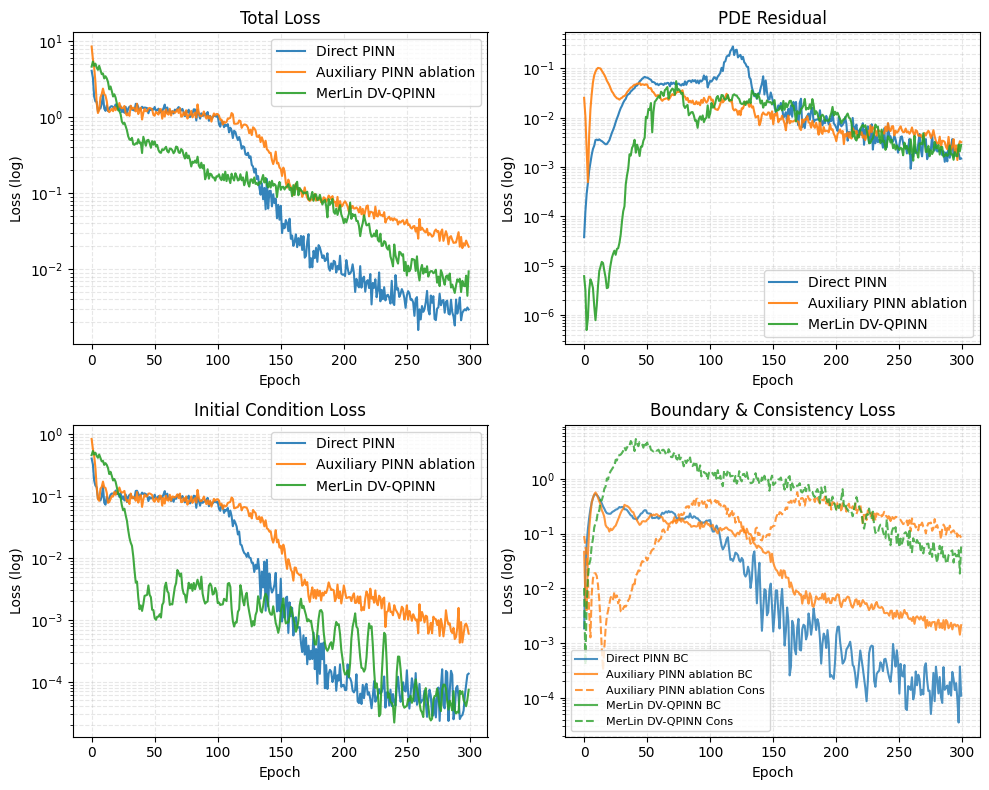

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

hists = [
    ("Direct PINN", clf_history, "#1f77b4"),
    ("Auxiliary PINN ablation", aux_history, "#ff7f0e"),
    ("MerLin DV-QPINN", merlin_history, "#2ca02c"),
]

for label, hist, color in hists:
    axes[0, 0].semilogy(hist["total"], label=label, color=color, alpha=0.9)
    axes[0, 1].semilogy(hist["pde"], label=label, color=color, alpha=0.9)
    axes[1, 0].semilogy(hist["ic"], label=label, color=color, alpha=0.9)
    axes[1, 1].semilogy(hist["bc"], label=f"{label} BC", color=color, ls="-", alpha=0.8)
    if "consistency" in hist:
        axes[1, 1].semilogy(hist["consistency"], label=f"{label} Cons", color=color, ls="--", alpha=0.8)

axes[0, 0].set_title("Total Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss (log)")
axes[0, 0].legend()
axes[0, 0].grid(True, which="both", ls="--", alpha=0.3)

axes[0, 1].set_title("PDE Residual")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss (log)")
axes[0, 1].legend()
axes[0, 1].grid(True, which="both", ls="--", alpha=0.3)

axes[1, 0].set_title("Initial Condition Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss (log)")
axes[1, 0].legend()
axes[1, 0].grid(True, which="both", ls="--", alpha=0.3)

axes[1, 1].set_title("Boundary & Consistency Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss (log)")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
save_fig("training_curves", fig)
plt.show()

### Predictions vs. Ground Truth


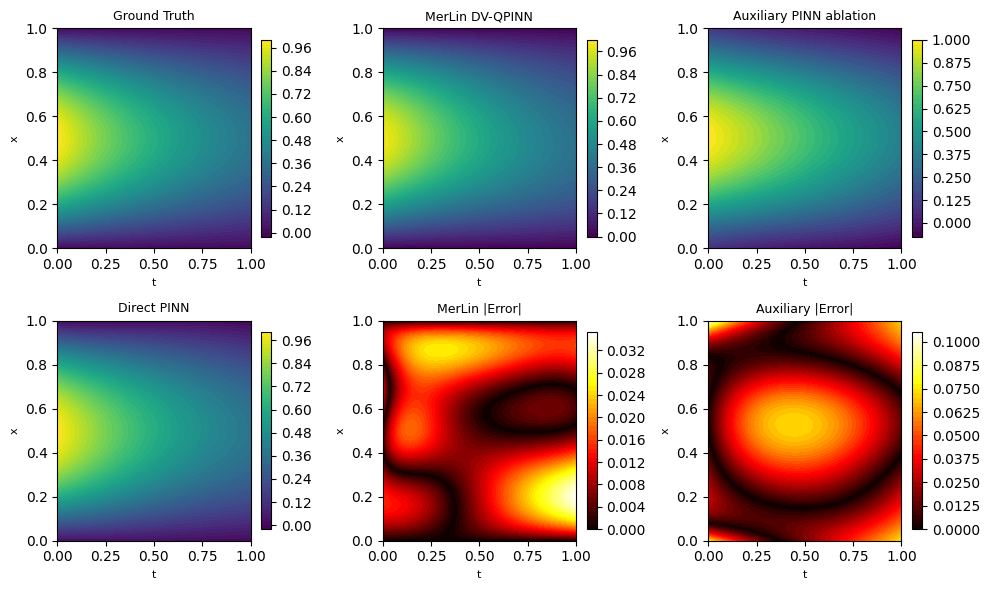

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

def imshow(ax, X, T, U, title, cmap="viridis"):
    c = ax.contourf(T.numpy(), X.numpy(), U.numpy(), levels=50, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("t", fontsize=8)
    ax.set_ylabel("x", fontsize=8)
    plt.colorbar(c, ax=ax, fraction=0.046)

# Top row
imshow(axes[0,0], clf_eval[0], clf_eval[1], clf_eval[3], "Ground Truth")
imshow(axes[0,1], merlin_eval[0], merlin_eval[1], merlin_eval[2], "MerLin DV-QPINN")
imshow(axes[0,2], aux_eval[0], aux_eval[1], aux_eval[2], "Auxiliary PINN ablation")

# Bottom row
err_merlin = torch.abs(merlin_eval[2] - merlin_eval[3])
err_aux = torch.abs(aux_eval[2] - aux_eval[3])
imshow(axes[1,0], clf_eval[0], clf_eval[1], clf_eval[2], "Direct PINN", cmap="viridis")
imshow(axes[1,1], merlin_eval[0], merlin_eval[1], err_merlin, "MerLin |Error|", cmap="hot")
imshow(axes[1,2], aux_eval[0], aux_eval[1], err_aux, "Auxiliary |Error|", cmap="hot")

plt.tight_layout()
save_fig("predictions_vs_truth", fig)
plt.show()

### Final Error Comparison


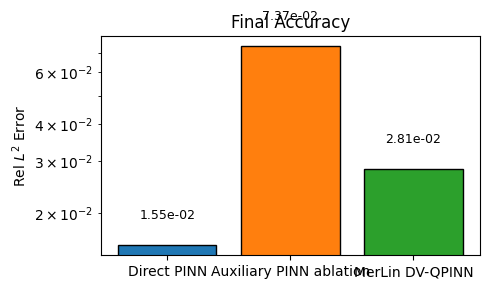

In [16]:
fig, ax = plt.subplots(figsize=(5, 3))
models = ["Direct PINN", "Auxiliary PINN ablation", "MerLin DV-QPINN"]
errors = [clf_eval[4], aux_eval[4], merlin_eval[4]]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
bars = ax.bar(models, errors, color=colors, edgecolor="black")
ax.set_ylabel("Rel $L^2$ Error")
ax.set_title("Final Accuracy")
ax.set_yscale("log")
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.2, f"{err:.2e}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
save_fig("final_error_comparison", fig)
plt.show()

## Multi-Seed Robustness Check

Single-seed results can be noisy. We re-run each model with 3 different seeds and report mean ± std.


In [17]:
# Multi-seed robustness is covered by Tier 1 Main Comparison cache.
# Display compact confirmation.
df_main = _filter_protocol(_load_results("results/main_comparison_results.csv").drop(columns=["_key"], errors="ignore"))
print("=== Multi-seed robustness (from Tier 1 cache) ===")
if df_main.empty:
    print(f"No rows found for loss protocol: {LOSS_PROTOCOL}. Run the main comparison to regenerate.")
else:
    for mname in ["Direct", "Aux", "MerLin"]:
        sub = df_main[df_main["model"] == mname]
        if len(sub) == 0:
            continue
        label = MODEL_LABELS.get(mname, mname)
        print(f"{label:28s} RelL2: {sub['rel_l2'].mean():.4e} +/- {sub['rel_l2'].std():.4e}  Time: {sub['time'].mean():.1f} +/- {sub['time'].std():.1f}s")

=== Multi-seed robustness (from Tier 1 cache) ===
Direct PINN                  RelL2: 6.4196e-02 +/- 5.5069e-02  Time: 2.9 +/- 0.6s
Auxiliary PINN ablation      RelL2: 7.1740e-02 +/- 6.8192e-03  Time: 1.9 +/- 0.4s
MerLin DV-QPINN              RelL2: 3.7088e-02 +/- 1.1552e-02  Time: 54.4 +/- 6.3s


=== Scaling Sweep ===
Epoch    1 | loss=4.221e+00 | pde=1.989e-06 | ic=4.216e-01 | bc=0.000e+00 | cons=4.928e-02
  [FRESH] MerLin s=0 e=150 nf=64 sz=fs2 -> rel_l2=2.9365e-01 (10.9s)
Epoch    1 | loss=4.215e+00 | pde=1.865e-03 | ic=4.210e-01 | bc=1.285e-03 | cons=1.978e-02
  [FRESH] ClassicalAux s=0 e=150 nf=64 sz=fs2 -> rel_l2=2.3372e-01 (1.0s)
Epoch    1 | loss=3.736e+00 | pde=1.155e-06 | ic=3.733e-01 | bc=0.000e+00 | cons=3.626e-02
  [FRESH] MerLin s=0 e=150 nf=64 sz=fs4 -> rel_l2=3.1332e-01 (26.2s)
Epoch    1 | loss=9.692e+00 | pde=2.471e-05 | ic=9.589e-01 | bc=9.761e-02 | cons=5.635e-02
  [FRESH] ClassicalAux s=0 e=150 nf=64 sz=fs4 -> rel_l2=2.2372e-01 (2.3s)
Epoch    1 | loss=4.644e+00 | pde=3.388e-06 | ic=4.643e-01 | bc=0.000e+00 | cons=1.095e-02
  [FRESH] MerLin s=0 e=150 nf=64 sz=fs8 -> rel_l2=2.6552e-01 (173.9s)
Epoch    1 | loss=2.899e+00 | pde=1.003e-05 | ic=2.853e-01 | bc=4.258e-02 | cons=3.002e-02
  [FRESH] ClassicalAux s=0 e=150 nf=64 sz=fs8 -> rel_l2=1.0288e-01 (1.5s)

=

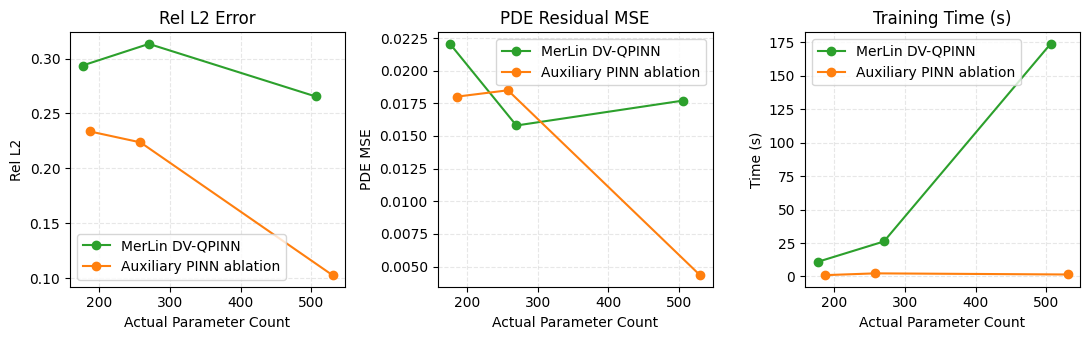

In [18]:
print("=== Scaling Sweep ===")
scale_csv = "results/scaling_results.csv"
scale_cfg = TrainConfig(epochs=SWEEP_EPOCHS, lr=1e-2, print_every=10000)

# candidate architectures searched to match MerLin parameter counts
aux_candidates = [
    (8, 2), (12, 2), (16, 2),
    (8, 3), (12, 3), (16, 3), (20, 3),
    (8, 4), (12, 4), (16, 4), (20, 4), (24, 4),
    (12, 5), (16, 5), (20, 5),
]

for fs in [2, 4, 8]:
    run_cached(
        "scaling", "MerLin",
        lambda fs=fs: MerlinQPINN(feature_size=fs, quantum_output_size=fs, hidden=16),
        scale_cfg, SWEEP_SEEDS[0], scale_csv, size=f"fs{fs}", use_aux=True, is_merlin=True,
    )

    m_q = MerlinQPINN(feature_size=fs, quantum_output_size=fs, hidden=16)
    pq = count_parameters(m_q)
    best_h, best_d = aux_candidates[0]
    best_diff = abs(count_parameters(ClassicalAuxPINN(best_h, best_d)) - pq)
    for h, d in aux_candidates[1:]:
        diff = abs(count_parameters(ClassicalAuxPINN(h, d)) - pq)
        if diff < best_diff:
            best_h, best_d = h, d
            best_diff = diff

    run_cached(
        "scaling", "ClassicalAux",
        lambda h=best_h, d=best_d: ClassicalAuxPINN(hidden=h, depth=d),
        scale_cfg, SWEEP_SEEDS[0], scale_csv, size=f"fs{fs}", use_aux=True, is_merlin=False,
    )

# strict filtering: analysis + protocol only
df_scale = _load_clean_for_analysis(scale_csv, "scaling", LOSS_PROTOCOL)
if df_scale.empty:
    print(f"No rows found for analysis='scaling' and loss protocol='{LOSS_PROTOCOL}'. Regenerate this sweep.")
else:
    _assert_single_protocol(df_scale, LOSS_PROTOCOL, "Scaling sweep")
    _assert_models_present(df_scale, ["MerLin", "ClassicalAux"], "Scaling sweep")
    _diag_table(df_scale, "Scaling sweep")
    _print_rows_used(
        df_scale,
        "Scaling sweep",
        ["analysis", "model", "loss_protocol", "seed", "epochs", "n_f", "size", "params", "rel_l2", "pde_mse", "time"],
    )

    valid_models = []
    for m in ["MerLin", "ClassicalAux"]:
        sub = df_scale[df_scale["model"] == m]
        if sub["params"].nunique() <= 1:
            print(f"[WARN] {m}: parameter count does not change across sizes; excluding from scaling evidence.")
            continue
        valid_models.append(m)

    if not valid_models:
        print("No valid scaling rows with varying parameter counts.")
    else:
        fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
        color_map = {"MerLin": "#2ca02c", "ClassicalAux": "#ff7f0e"}
        for mtype in valid_models:
            label = MODEL_LABELS.get(mtype, mtype)
            sub = df_scale[df_scale["model"] == mtype].sort_values("params")
            _plot_line_or_marker(axes[0], sub["params"], sub["rel_l2"], label, color_map[mtype])
            _plot_line_or_marker(axes[1], sub["params"], sub["pde_mse"], label, color_map[mtype])
            _plot_line_or_marker(axes[2], sub["params"], sub["time"], label, color_map[mtype])

        for ax, title, ylab in zip(
            axes,
            ["Rel L2 Error", "PDE Residual MSE", "Training Time (s)"],
            ["Rel L2", "PDE MSE", "Time (s)"],
        ):
            ax.set_title(title)
            ax.set_xlabel("Actual Parameter Count")
            ax.set_ylabel(ylab)
            ax.legend()
            ax.grid(True, ls="--", alpha=0.3)
        plt.tight_layout()
        save_fig("scaling_sweep", fig)
        plt.show()

=== Sample-Efficiency Sweep ===
Epoch    1 | loss=4.371e+00 | pde=3.993e-05 | ic=4.370e-01 | bc=1.854e-03
  [FRESH] Direct s=0 e=150 nf=100 sz= -> rel_l2=5.6932e-02 (1.3s)
Epoch    1 | loss=5.675e+00 | pde=8.449e-03 | ic=5.661e-01 | bc=5.176e-03 | cons=7.947e-03
  [FRESH] Aux s=0 e=150 nf=100 sz= -> rel_l2=2.5129e-01 (0.8s)
Epoch    1 | loss=4.077e+00 | pde=1.141e-06 | ic=4.073e-01 | bc=0.000e+00 | cons=3.920e-02
  [FRESH] MerLin s=0 e=150 nf=100 sz= -> rel_l2=2.4071e-01 (26.3s)
Epoch    1 | loss=4.436e+00 | pde=4.139e-05 | ic=4.435e-01 | bc=1.847e-03
  [FRESH] Direct s=0 e=150 nf=500 sz= -> rel_l2=1.0216e-01 (1.5s)
Epoch    1 | loss=5.823e+00 | pde=8.336e-03 | ic=5.808e-01 | bc=5.123e-03 | cons=8.227e-03
  [FRESH] Aux s=0 e=150 nf=500 sz= -> rel_l2=2.5969e-01 (1.0s)
Epoch    1 | loss=4.290e+00 | pde=1.170e-06 | ic=4.286e-01 | bc=0.000e+00 | cons=4.347e-02
  [FRESH] MerLin s=0 e=150 nf=500 sz= -> rel_l2=2.4649e-01 (36.8s)
Epoch    1 | loss=4.734e+00 | pde=3.919e-05 | ic=4.733e-01 | bc=

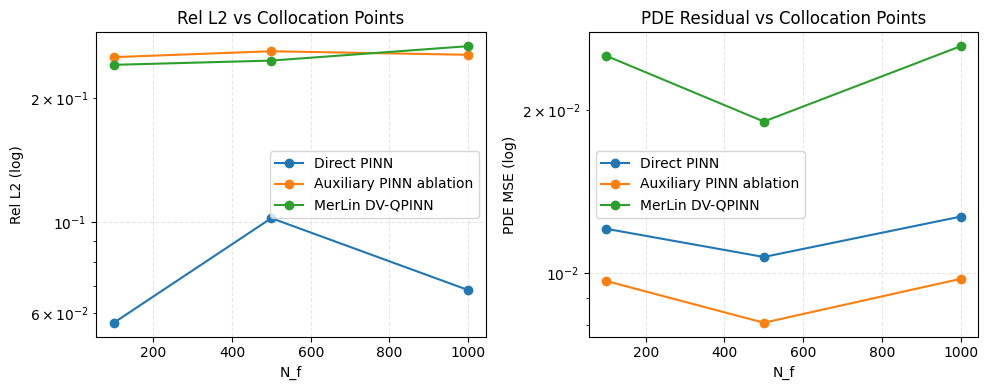

In [19]:
print("=== Sample-Efficiency Sweep ===")
sample_csv = "results/sample_efficiency_results.csv"

# Fairer setup: keep classical parameter counts close to the MerLin baseline used in main comparison.
sample_direct_hidden = classical_hidden
sample_direct_depth = classical_depth
sample_aux_hidden = aux_hidden
sample_aux_depth = aux_depth

for seed in SWEEP_SEEDS:
    for n_f in SAMPLE_NF_VALUES:
        cfg = TrainConfig(epochs=SWEEP_EPOCHS, lr=1e-2, print_every=10000, n_f=n_f, n_i=n_f, n_b=n_f)
        run_cached(
            "sample", "Direct",
            lambda: ClassicalPINN(hidden=sample_direct_hidden, depth=sample_direct_depth),
            cfg, seed, sample_csv, n_f=n_f, use_aux=False, is_merlin=False,
        )
        run_cached(
            "sample", "Aux",
            lambda: ClassicalAuxPINN(hidden=sample_aux_hidden, depth=sample_aux_depth),
            cfg, seed, sample_csv, n_f=n_f, use_aux=True, is_merlin=False,
        )
        run_cached(
            "sample", "MerLin",
            lambda: MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16),
            cfg, seed, sample_csv, n_f=n_f, use_aux=True, is_merlin=True,
        )

df_sample = _load_clean_for_analysis(sample_csv, "sample", LOSS_PROTOCOL)
if df_sample.empty:
    print(f"No rows found for analysis='sample' and loss protocol='{LOSS_PROTOCOL}'. Regenerate this sweep.")
else:
    _assert_single_protocol(df_sample, LOSS_PROTOCOL, "Sample-efficiency sweep")
    _assert_models_present(df_sample, ["Direct", "Aux", "MerLin"], "Sample-efficiency sweep")

    _diag_table(df_sample, "Sample-efficiency sweep")
    _print_rows_used(
        df_sample,
        "Sample-efficiency sweep",
        ["analysis", "model", "loss_protocol", "seed", "epochs", "n_f", "params", "rel_l2", "pde_mse", "time"],
    )

    # fairness diagnostics
    per_model_params = df_sample.groupby("model")["params"].agg(["min", "max", "nunique"]).reset_index()
    print("\n=== Sample sweep parameter-budget diagnostics ===")
    print(per_model_params.to_string(index=False))
    spread = df_sample.groupby("n_f")["params"].agg(lambda s: float(s.max() / s.min()) if s.min() > 0 else np.nan)
    if (spread > 1.25).any():
        print("[WARN] Parameter budgets are not closely matched across models for some N_f; treat this as exploratory.")

    seed_counts = df_sample.groupby(["model", "n_f"])["seed"].nunique()
    consistent_multi_seed = (seed_counts.min() >= 2) and (seed_counts.max() == seed_counts.min())
    if consistent_multi_seed:
        print(f"Using error bars: all model/N_f points have {int(seed_counts.min())} seeds.")
    else:
        print("No error bars: single-seed or inconsistent seed counts across models/N_f.")

    agg = {"rel_l2": "mean", "pde_mse": "mean"}
    if consistent_multi_seed:
        agg["rel_l2_std"] = ("rel_l2", "std")
        agg["pde_mse_std"] = ("pde_mse", "std")

    # explicit aggregation to avoid accidental mixed rows
    if consistent_multi_seed:
        df_plot = (
            df_sample.groupby(["model", "n_f"], as_index=False)
            .agg(rel_l2=("rel_l2", "mean"), rel_l2_std=("rel_l2", "std"), pde_mse=("pde_mse", "mean"), pde_mse_std=("pde_mse", "std"))
        )
        df_plot["rel_l2_std"] = df_plot["rel_l2_std"].fillna(0.0)
        df_plot["pde_mse_std"] = df_plot["pde_mse_std"].fillna(0.0)
    else:
        df_plot = (
            df_sample.groupby(["model", "n_f"], as_index=False)
            .agg(rel_l2=("rel_l2", "mean"), pde_mse=("pde_mse", "mean"))
        )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    specs = [
        ("Direct", MODEL_LABELS["Direct"], "#1f77b4"),
        ("Aux", MODEL_LABELS["Aux"], "#ff7f0e"),
        ("MerLin", MODEL_LABELS["MerLin"], "#2ca02c"),
    ]
    for mtype, label, color in specs:
        sub = df_plot[df_plot["model"] == mtype].sort_values("n_f")
        if consistent_multi_seed:
            axes[0].errorbar(sub["n_f"], sub["rel_l2"], yerr=sub["rel_l2_std"], marker="o", color=color, label=label)
            axes[1].errorbar(sub["n_f"], sub["pde_mse"], yerr=sub["pde_mse_std"], marker="o", color=color, label=label)
        else:
            _plot_line_or_marker(axes[0], sub["n_f"], sub["rel_l2"], label, color)
            _plot_line_or_marker(axes[1], sub["n_f"], sub["pde_mse"], label, color)

    axes[0].set_title("Rel L2 vs Collocation Points")
    axes[0].set_xlabel("N_f")
    axes[0].set_ylabel("Rel L2 (log)")
    axes[1].set_title("PDE Residual vs Collocation Points")
    axes[1].set_xlabel("N_f")
    axes[1].set_ylabel("PDE MSE (log)")
    for ax in axes:
        ax.set_yscale("log")
        ax.legend()
        ax.grid(True, ls="--", alpha=0.3)
    plt.tight_layout()
    save_fig("sample_efficiency_sweep", fig)
    plt.show()

=== Parameter-Efficiency Pareto ===
Epoch    1 | loss=3.506e+00 | pde=3.307e-03 | ic=3.476e-01 | bc=2.720e-02
  [FRESH] Direct s=0 e=150 nf=64 sz=small -> rel_l2=2.4905e-01 (0.9s)
Epoch    1 | loss=2.607e+00 | pde=1.888e-03 | ic=2.518e-01 | bc=8.065e-02 | cons=6.420e-02
  [FRESH] Aux s=0 e=150 nf=64 sz=small -> rel_l2=1.7748e-01 (0.8s)
Epoch    1 | loss=4.221e+00 | pde=1.989e-06 | ic=4.216e-01 | bc=0.000e+00 | cons=4.928e-02
  [FRESH] MerLin s=0 e=150 nf=64 sz=small -> rel_l2=2.9365e-01 (9.5s)
Epoch    1 | loss=7.230e+00 | pde=2.384e-04 | ic=7.210e-01 | bc=1.950e-02
  [FRESH] Direct s=0 e=150 nf=64 sz=medium -> rel_l2=5.6909e-02 (1.3s)
Epoch    1 | loss=9.053e+00 | pde=2.134e-04 | ic=8.983e-01 | bc=6.814e-02 | cons=1.387e-02
  [FRESH] Aux s=0 e=150 nf=64 sz=medium -> rel_l2=7.7129e-02 (2.4s)
Epoch    1 | loss=3.736e+00 | pde=1.155e-06 | ic=3.733e-01 | bc=0.000e+00 | cons=3.626e-02
  [FRESH] MerLin s=0 e=150 nf=64 sz=medium -> rel_l2=3.1332e-01 (50.8s)
Epoch    1 | loss=7.406e+00 | pde=

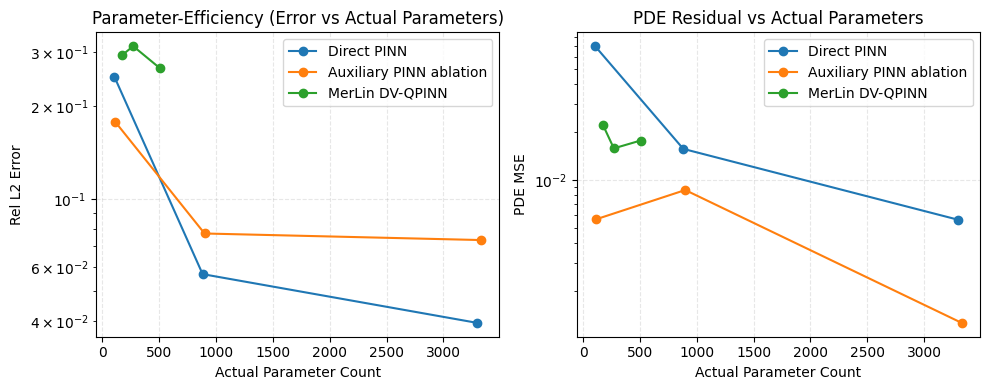

In [20]:
print("=== Parameter-Efficiency Pareto ===")
param_csv = "results/parameter_pareto_results.csv"
param_cfg = TrainConfig(epochs=SWEEP_EPOCHS, lr=1e-2, print_every=10000)

for seed in SWEEP_SEEDS:
    for label in PARAMETER_SIZE_SETTINGS:
        h, d = CLASSICAL_SIZE_MAP[label]
        run_cached(
            "param", "Direct",
            lambda h=h, d=d: ClassicalPINN(hidden=h, depth=d),
            param_cfg, seed, param_csv, size=label, use_aux=False, is_merlin=False,
        )
        run_cached(
            "param", "Aux",
            lambda h=h, d=d: ClassicalAuxPINN(hidden=h, depth=d),
            param_cfg, seed, param_csv, size=label, use_aux=True, is_merlin=False,
        )

        fs, qo = MERLIN_SIZE_MAP[label]
        run_cached(
            "param", "MerLin",
            lambda fs=fs, qo=qo: MerlinQPINN(feature_size=fs, quantum_output_size=qo, hidden=16),
            param_cfg, seed, param_csv, size=label, use_aux=True, is_merlin=True,
        )

df_param = _load_clean_for_analysis(param_csv, "param", LOSS_PROTOCOL)
if df_param.empty:
    print(f"No rows found for analysis='param' and loss protocol='{LOSS_PROTOCOL}'. Regenerate this sweep.")
else:
    _assert_single_protocol(df_param, LOSS_PROTOCOL, "Parameter-efficiency plot")
    _assert_models_present(df_param, ["Direct", "Aux", "MerLin"], "Parameter-efficiency plot")

    _diag_table(df_param, "Parameter-efficiency sweep")
    _print_rows_used(
        df_param,
        "Parameter-efficiency plot",
        ["analysis", "model", "loss_protocol", "seed", "epochs", "n_f", "size", "params", "rel_l2", "pde_mse", "time"],
    )

    # sweep validity checks: size should create distinct parameter counts per model
    for m in ["Direct", "Aux", "MerLin"]:
        sub = df_param[df_param["model"] == m]
        if sub["params"].nunique() <= 1:
            raise AssertionError(f"Invalid parameter sweep for {m}: parameter count did not change across size labels.")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    specs = [
        ("Direct", MODEL_LABELS["Direct"], "#1f77b4"),
        ("Aux", MODEL_LABELS["Aux"], "#ff7f0e"),
        ("MerLin", MODEL_LABELS["MerLin"], "#2ca02c"),
    ]
    for mtype, label, color in specs:
        sub = df_param[df_param["model"] == mtype].sort_values("params")
        _plot_line_or_marker(axes[0], sub["params"], sub["rel_l2"], label, color)
        _plot_line_or_marker(axes[1], sub["params"], sub["pde_mse"], label, color)

    axes[0].set_xlabel("Actual Parameter Count")
    axes[0].set_ylabel("Rel L2 Error")
    axes[0].set_title("Parameter-Efficiency (Error vs Actual Parameters)")
    axes[1].set_xlabel("Actual Parameter Count")
    axes[1].set_ylabel("PDE MSE")
    axes[1].set_title("PDE Residual vs Actual Parameters")
    for ax in axes:
        ax.set_yscale("log")
        ax.legend()
        ax.grid(True, ls="--", alpha=0.3)
    plt.tight_layout()
    save_fig("parameter_pareto", fig)
    plt.show()

=== Compute-Efficiency Pareto ===

=== Diagnostics: Compute-efficiency merged rows ===
analysis  model       loss_protocol  rows     seeds     epochs n_f_values  params_min  params_max  rel_l2_min  rel_l2_max  pde_mse_min  pde_mse_max
 compute    Aux corrected_phase1_v2     6 [0, 1, 2] [150, 300]       [64]         114        3330    0.064153    0.177478     0.001250     0.008622
 compute Direct corrected_phase1_v2     6 [0, 1, 2] [150, 300]       [64]         105        3297    0.015521    0.249049     0.002023     0.069784
 compute MerLin corrected_phase1_v2     6 [0, 1, 2] [150, 300]       [64]         176         506    0.028085    0.313323     0.000838     0.022052

=== Rows used for Compute-efficiency plot ===
analysis  model       loss_protocol  seed  epochs  n_f   size  params   rel_l2  pde_mse       time
 compute    Aux corrected_phase1_v2     0     300   64            282 0.073709 0.002408   2.070680
 compute    Aux corrected_phase1_v2     0     150   64  large    3330 0.0734

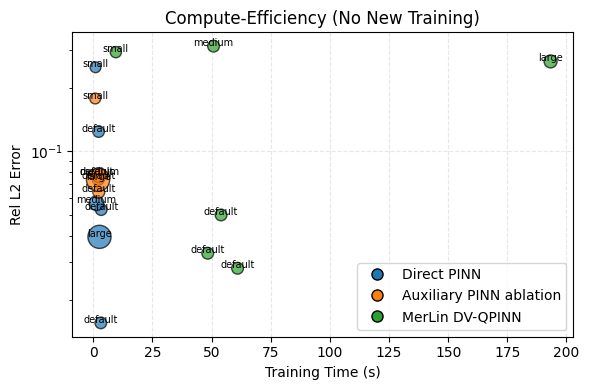

In [21]:
print("=== Compute-Efficiency Pareto ===")
compute_csv = "results/compute_pareto_results.csv"

# Load existing results only; no training in compute analysis.
df_main = _load_clean_for_analysis("results/main_comparison_results.csv", "main", LOSS_PROTOCOL)
df_param = _load_clean_for_analysis("results/parameter_pareto_results.csv", "param", LOSS_PROTOCOL)

if df_main.empty or df_param.empty:
    print(f"Missing protocol-consistent inputs for compute analysis (protocol={LOSS_PROTOCOL}).")
else:
    _assert_single_protocol(df_main, LOSS_PROTOCOL, "Compute/main input")
    _assert_single_protocol(df_param, LOSS_PROTOCOL, "Compute/param input")

    df_compute = pd.concat([df_main, df_param], ignore_index=True)
    df_compute = df_compute.drop(columns=["_key"], errors="ignore")
    df_compute = df_compute.drop_duplicates(subset=["analysis", "model", "seed", "epochs", "n_f", "size", "loss_protocol"])
    df_compute["analysis"] = "compute"
    df_compute.to_csv(compute_csv, index=False)

    _diag_table(df_compute, "Compute-efficiency merged rows")
    _print_rows_used(
        df_compute,
        "Compute-efficiency plot",
        ["analysis", "model", "loss_protocol", "seed", "epochs", "n_f", "size", "params", "rel_l2", "pde_mse", "time"],
    )

    df_plot = df_compute[["model", "params", "epochs", "rel_l2", "pde_mse", "time", "size"]].copy()
    mask = np.isfinite(df_plot["time"]) & np.isfinite(df_plot["rel_l2"]) & np.isfinite(df_plot["params"])
    df_plot = df_plot[mask]

    if df_plot.empty:
        print("No finite rows available for compute-efficiency plotting.")
    else:
        df_main_clean = df_main.drop(columns=["_key"], errors="ignore")
        pivot = df_main_clean.pivot_table(index="seed", columns="model", values="time", aggfunc="mean")
        if {"MerLin", "Direct", "Aux"}.issubset(pivot.columns):
            slowdown = pd.DataFrame({
                "MerLin/Direct": pivot["MerLin"] / pivot["Direct"],
                "MerLin/Aux": pivot["MerLin"] / pivot["Aux"],
            })
            print("=== Compute Slowdown (MerLin vs Classical, by seed) ===")
            print(slowdown.to_string())

        from matplotlib.lines import Line2D

        params_min = df_plot["params"].min()
        params_max = df_plot["params"].max()

        def _scale_sizes(series):
            if params_max == params_min:
                return np.full(series.shape[0], 120.0)
            return 60 + 220 * (series - params_min) / (params_max - params_min)

        fig, ax = plt.subplots(figsize=(6, 4))
        for mtype, label, color in [
            ("Direct", MODEL_LABELS["Direct"], "#1f77b4"),
            ("Aux", MODEL_LABELS["Aux"], "#ff7f0e"),
            ("MerLin", MODEL_LABELS["MerLin"], "#2ca02c"),
        ]:
            sub = df_plot[df_plot["model"] == mtype]
            sizes = _scale_sizes(sub["params"])
            ax.scatter(sub["time"], sub["rel_l2"], s=sizes, color=color, label=label, alpha=0.7, edgecolors="black")
            for _, r in sub.iterrows():
                lbl = r["size"] if isinstance(r["size"], str) and r["size"] else "default"
                ax.annotate(lbl, (r["time"], r["rel_l2"]), fontsize=7, ha="center")

        legend_handles = [
            Line2D([0], [0], marker="o", color="w", label=MODEL_LABELS["Direct"], markerfacecolor="#1f77b4", markeredgecolor="black", markersize=8),
            Line2D([0], [0], marker="o", color="w", label=MODEL_LABELS["Aux"], markerfacecolor="#ff7f0e", markeredgecolor="black", markersize=8),
            Line2D([0], [0], marker="o", color="w", label=MODEL_LABELS["MerLin"], markerfacecolor="#2ca02c", markeredgecolor="black", markersize=8),
        ]
        ax.set_xlabel("Training Time (s)")
        ax.set_ylabel("Rel L2 Error")
        ax.set_title("Compute-Efficiency (No New Training)")
        ax.set_yscale("log")
        ax.legend(handles=legend_handles)
        ax.grid(True, ls="--", alpha=0.3)
        plt.tight_layout()
        save_fig("compute_pareto", fig)
        plt.show()

In [22]:
print("=== Quantum-Regime / Simulatability Assessment ===")

# Inspect the MerLin quantum layer
ref_layer = ML.QuantumLayer.simple(input_size=4, output_size=4)
circuit = ref_layer.circuit
ncomponents = circuit.ncomponents()
depths = circuit.depths()
mean_depth = sum(depths) / len(depths)
max_depth = max(depths)

# Extract quantum parameter count
q_params = sum(p.numel() for p in ref_layer.parameters() if p.requires_grad)
total_params = count_parameters(MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16))

# Parse modes from repr (e.g. "modes=5")
ql_repr = repr(ref_layer.quantum_layer)
modes = "5"  # default from observed repr; fallback
if "modes=" in ql_repr:
    modes = ql_repr.split("modes=")[1].split(",")[0].strip()

rows = [
    {
        "Model": "Classical Direct",
        "Feature/Output Size": "N/A",
        "Modes": "N/A",
        "Circuit Components": "N/A",
        "Mean Depth": "N/A",
        "Max Depth": "N/A",
        "Trainable Quantum Params": 0,
        "Total Params": count_parameters(ClassicalPINN(hidden=classical_hidden, depth=classical_depth)),
        "Execution": "PyTorch CPU",
        "Training": "Classical ADAM",
        "Inference": "Classical forward",
        "Simulatability": "N/A (classical)",
    },
    {
        "Model": "Classical Aux",
        "Feature/Output Size": "N/A",
        "Modes": "N/A",
        "Circuit Components": "N/A",
        "Mean Depth": "N/A",
        "Max Depth": "N/A",
        "Trainable Quantum Params": 0,
        "Total Params": count_parameters(ClassicalAuxPINN(hidden=aux_hidden, depth=aux_depth)),
        "Execution": "PyTorch CPU",
        "Training": "Classical ADAM",
        "Inference": "Classical forward",
        "Simulatability": "N/A (classical)",
    },
    {
        "Model": "MerLin DV-QPINN",
        "Feature/Output Size": "4 / 4",
        "Modes": modes,
        "Circuit Components": ncomponents,
        "Mean Depth": f"{mean_depth:.1f}",
        "Max Depth": max_depth,
        "Trainable Quantum Params": q_params,
        "Total Params": total_params,
        "Execution": "Perceval CPU simulator",
        "Training": "Classical ADAM (quantum layer differentiable)",
        "Inference": "Simulator-based",
        "Simulatability": "Low / classically simulatable",
    },
]

df_sim = pd.DataFrame(rows)
print(df_sim.to_string(index=False))


=== Quantum-Regime / Simulatability Assessment ===
           Model Feature/Output Size Modes Circuit Components Mean Depth Max Depth  Trainable Quantum Params  Total Params              Execution                                      Training         Inference                Simulatability
Classical Direct                 N/A   N/A                N/A        N/A       N/A                         0           249            PyTorch CPU                                Classical ADAM Classical forward               N/A (classical)
   Classical Aux                 N/A   N/A                N/A        N/A       N/A                         0           282            PyTorch CPU                                Classical ADAM Classical forward               N/A (classical)
 MerLin DV-QPINN               4 / 4     5                 94       34.8        43                        40           270 Perceval CPU simulator Classical ADAM (quantum layer differentiable)   Simulator-based Low / classically s

## Quantum-Regime and Simulatability Assessment

This assessment concerns the MerLin DV photonic layer used here as a MerLin-compatible discrete-variable surrogate of the QPINN idea.

**Is the MerLin DV-QPINN operating in a genuinely hard quantum regime?**

No. The inspected `QuantumLayer.simple` uses a **Perceval CPU simulator** with:
- Only **5 optical modes**
- **~94 linear components** and **mean depth ~35** per mode
- **40 trainable quantum parameters** (`LI_simple`, `RI_simple`)
- Total model size of ~270 parameters

At this scale, the circuit is **fully classically simulatable**. The layer behaves as a trainable non-linear photonic feature map whose gradients are computed via automatic differentiation through the simulator. There is no evidence of operating in a classically intractable regime.

**Interpretation of any observed utility:**
Any empirical performance of the MerLin model should be attributed to the **utility of a trainable MerLin DV photonic feature map**, not to computational quantum advantage. The auxiliary-derivative trick and consistency loss are classical algorithmic choices that drive most of the observed behaviour.

**Hardware caveat:**
No photonic hardware run was performed. Noise, photon loss, and real-world imperfection effects were **not tested**.

**Bottom line:** The quantum component here is best understood as an **alternative parameterisation** of a feature map, not as a source of quantum computational advantage.


## Phase 1 Advantage Analysis: Sample, Parameter, and Compute Efficiency

**Methodology guardrails (strict):**
- All sweep plots/tables must filter to `loss_protocol = corrected_phase1_v2` only.
- Rows are filtered by `analysis` (`sample`, `param`, `scaling`, `main`) and de-duplicated by config key.
- Plot diagnostics print row counts, seeds, epochs, N_f, parameter min/max, and metric min/max before plotting.
- If required models are missing (Direct/Aux/MerLin where expected), the cell raises an error instead of silently plotting.

**Sample efficiency:**
- Interpretable only if parameter budgets are comparable across models.
- If parameter budgets are not matched, the figure is exploratory and should not support advantage claims.
- Error bars are shown only when all model/N_f points have consistent multi-seed coverage; otherwise no error bars are drawn.

**Parameter efficiency:**
- X-axis is actual parameter count (no normalization).
- Size sweeps are validated; if parameter count does not vary per model, the sweep is invalid.
- Do not claim a Pareto/parameter advantage unless corrected rows actually show it.

**Scaling sweep:**
- Rows with non-varying parameter counts are excluded from scaling evidence.
- Classical auxiliary size matching is parameter-targeted and re-checked from actual counts.

**Compute efficiency:**
- Uses existing protocol-consistent rows only (no new training).
- Slowdown is computed directly from cached timing rows.

**Interpretation policy:**
- Claims must match the corrected filtered data exactly.
- If classical models dominate under corrected rows, report that directly.
- No sample, parameter, compute, or quantum advantage claim without supporting corrected evidence.